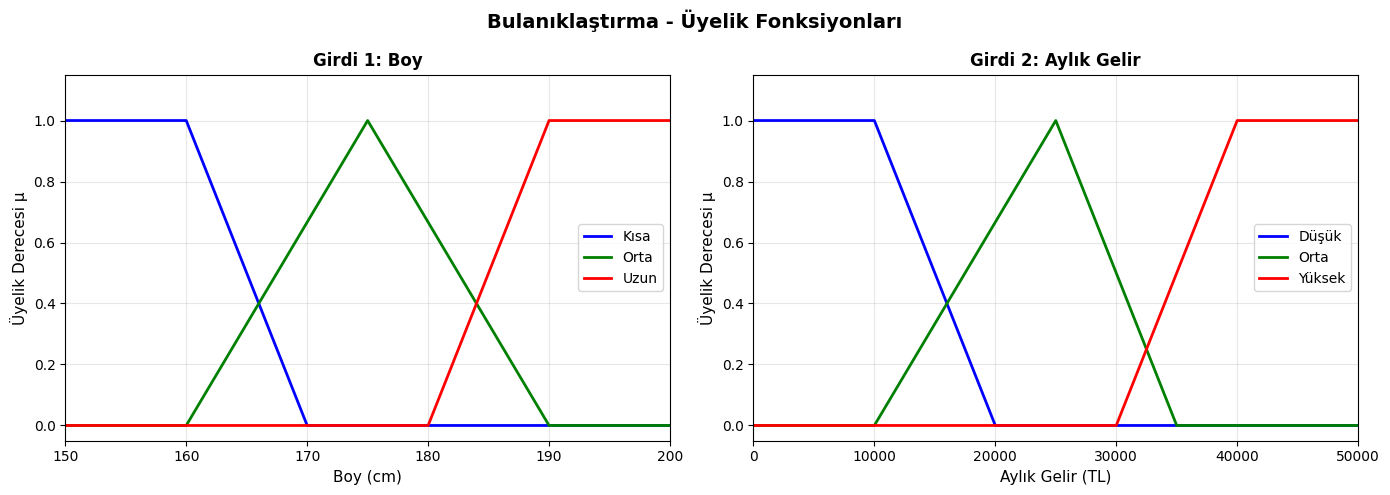

In [19]:
#FONKSİYONLAR VE GRAFİKLERi

import numpy as np
import matplotlib.pyplot as plt


# ÜYELİK FONKSİYONLARI - BOY
# Yamuk fonksiyon: 150-160 tam üye (1.0), 160-170 arası düşüş

def kisa_boy(x):
    if x <= 160: return 1.0               # 160 cm ve altı tamamen kısa
    elif x <= 170: return (170 - x) / 10  # 160-170 arası doğrusal azalış
    else: return 0.0                       # 170 cm üstü kısa değil

# Üçgen fonksiyon: 160'ta başlar, 175'te zirve, 190'da biter
def orta_boy(x):
    if x <= 160: return 0.0               # 160 cm altı orta değil
    elif x <= 175: return (x - 160) / 15  # 160-175 arası doğrusal artış
    elif x <= 190: return (190 - x) / 15  # 175-190 arası doğrusal azalış
    else: return 0.0                       # 190 cm üstü orta değil

# Yamuk fonksiyon: 180-190 arası yükseliş, 190 üstü tam üye (1.0)
def uzun_boy(x):
    if x <= 180: return 0.0               # 180 cm altı uzun değil
    elif x <= 190: return (x - 180) / 10  # 180-190 arası doğrusal artış
    else: return 1.0                       # 190 cm ve üstü tamamen uzun


# ÜYELİK FONKSİYONLARI - GELİR
# Yamuk fonksiyon: 0-10000 tam üye (1.0), 10000-20000 arası düşüş

def dusuk_gelir(x):
    if x <= 10000: return 1.0                       # 10.000 TL altı tamamen düşük
    elif x <= 20000: return (20000 - x) / 10000     # 10k-20k arası doğrusal azalış
    else: return 0.0                                 # 20.000 TL üstü düşük değil

# Üçgen fonksiyon: 10k'da başlar, 25k'da zirve, 35k'da biter
def orta_gelir(x):
    if x <= 10000: return 0.0                       # 10.000 TL altı orta değil
    elif x <= 25000: return (x - 10000) / 15000     # 10k-25k arası doğrusal artış
    elif x <= 35000: return (35000 - x) / 10000     # 25k-35k arası doğrusal azalış
    else: return 0.0                                 # 35.000 TL üstü orta değil

# Yamuk fonksiyon: 30k-40k arası yükseliş, 40k üstü tam üye (1.0)
def yuksek_gelir(x):
    if x <= 30000: return 0.0                       # 30.000 TL altı yüksek değil
    elif x <= 40000: return (x - 30000) / 10000     # 30k-40k arası doğrusal artış
    else: return 1.0                                 # 40.000 TL üstü tamamen yüksek


# GRAFİKLERİ ÇİZME KISMI

boy_aralik   = np.arange(150, 201, 1)
gelir_aralik = np.arange(0, 50001, 100)

mu_kisa  = [kisa_boy(x)   for x in boy_aralik]
mu_orta  = [orta_boy(x)   for x in boy_aralik]
mu_uzun  = [uzun_boy(x)   for x in boy_aralik]

mu_dusuk  = [dusuk_gelir(x)  for x in gelir_aralik]
mu_orta_g = [orta_gelir(x)   for x in gelir_aralik]
mu_yuksek = [yuksek_gelir(x) for x in gelir_aralik]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bulanıklaştırma - Üyelik Fonksiyonları", fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(boy_aralik, mu_kisa, 'b-', linewidth=2, label='Kısa')
ax1.plot(boy_aralik, mu_orta, 'g-', linewidth=2, label='Orta')
ax1.plot(boy_aralik, mu_uzun, 'r-', linewidth=2, label='Uzun')
ax1.set_xlabel('Boy (cm)', fontsize=11)
ax1.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax1.set_title('Girdi 1: Boy', fontsize=12, fontweight='bold')
ax1.set_ylim(-0.05, 1.15)
ax1.set_xlim(150, 200)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(gelir_aralik, mu_dusuk,  'b-', linewidth=2, label='Düşük')
ax2.plot(gelir_aralik, mu_orta_g, 'g-', linewidth=2, label='Orta')
ax2.plot(gelir_aralik, mu_yuksek, 'r-', linewidth=2, label='Yüksek')
ax2.set_xlabel('Aylık Gelir (TL)', fontsize=11)
ax2.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax2.set_title('Girdi 2: Aylık Gelir', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.05, 1.15)
ax2.set_xlim(0, 50000)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# KULLANICIDAN GİRİŞ ALMA KISMI


# Kullanıcıdan giriş alma
boy_giris   = float(input("Boy değerini giriniz (cm) [150-200]: "))
gelir_giris = float(input("Aylık gelir giriniz (TL) [0-50000]: "))


# BULANIKLAŞTIRMA - BOY
# Her üyelik fonksiyonu çağrılır ve sonuç 0-1 arasında üyelik derecesi döner

b_kisa = kisa_boy(boy_giris)   # Girilen boy "kısa" kümesine ne kadar üye?
b_orta = orta_boy(boy_giris)   # Girilen boy "orta" kümesine ne kadar üye?
b_uzun = uzun_boy(boy_giris)   # Girilen boy "uzun" kümesine ne kadar üye?


# BULANIKLAŞTIRMA - GELİR

g_dusuk  = dusuk_gelir(gelir_giris)   # Girilen gelir "düşük"  kümesine ne kadar üye?
g_orta   = orta_gelir(gelir_giris)    # Girilen gelir "orta"   kümesine ne kadar üye?
g_yuksek = yuksek_gelir(gelir_giris)  # Girilen gelir "yüksek" kümesine ne kadar üye?

# SONUÇLARI SÖZLÜĞE ATMA - ilerleyen aşamalarda kolaylık olması için tercih ettim hocam.
# İleride kural tablosu ve çıkarım aşamasında bu sözlükler kullanılacak
# Erişim örneği: bulanik_boy["orta"] --> 0.8

bulanik_boy = {
    "kisa": b_kisa,   # "kısa" kümesindeki üyelik derecesi
    "orta": b_orta,   # "orta" kümesindeki üyelik derecesi
    "uzun": b_uzun    # "uzun" kümesindeki üyelik derecesi
}

bulanik_gelir = {
    "dusuk":  g_dusuk,   # "düşük"  kümesindeki üyelik derecesi
    "orta":   g_orta,    # "orta"   kümesindeki üyelik derecesi
    "yuksek": g_yuksek   # "yüksek" kümesindeki üyelik derecesi
}

# Sonuçları yazdırma kısmı
print("\n" + "="*45)
print(f"  BOY GİRİŞİ: {boy_giris} cm")
print("="*45)
for kume, derece in bulanik_boy.items():
    print(f"  {kume.capitalize():<8} üyelik derecesi: {derece:.4f}")

print("\n" + "="*45)
print(f"  GELİR GİRİŞİ: {gelir_giris:,.0f} TL")
print("="*45)
for kume, derece in bulanik_gelir.items():
    print(f"  {kume.capitalize():<8} üyelik derecesi: {derece:.4f}")

print("\n--- Sözlük içerikleri ---")
print(f"bulanik_boy   = {bulanik_boy}")
print(f"bulanik_gelir = {bulanik_gelir}")

Boy değerini giriniz (cm) [150-200]: 165
Aylık gelir giriniz (TL) [0-50000]: 31236

  BOY GİRİŞİ: 165.0 cm
  Kisa     üyelik derecesi: 0.5000
  Orta     üyelik derecesi: 0.3333
  Uzun     üyelik derecesi: 0.0000

  GELİR GİRİŞİ: 31,236 TL
  Dusuk    üyelik derecesi: 0.0000
  Orta     üyelik derecesi: 0.3764
  Yuksek   üyelik derecesi: 0.1236

--- Sözlük içerikleri ---
bulanik_boy   = {'kisa': 0.5, 'orta': 0.3333333333333333, 'uzun': 0.0}
bulanik_gelir = {'dusuk': 0.0, 'orta': 0.3764, 'yuksek': 0.1236}


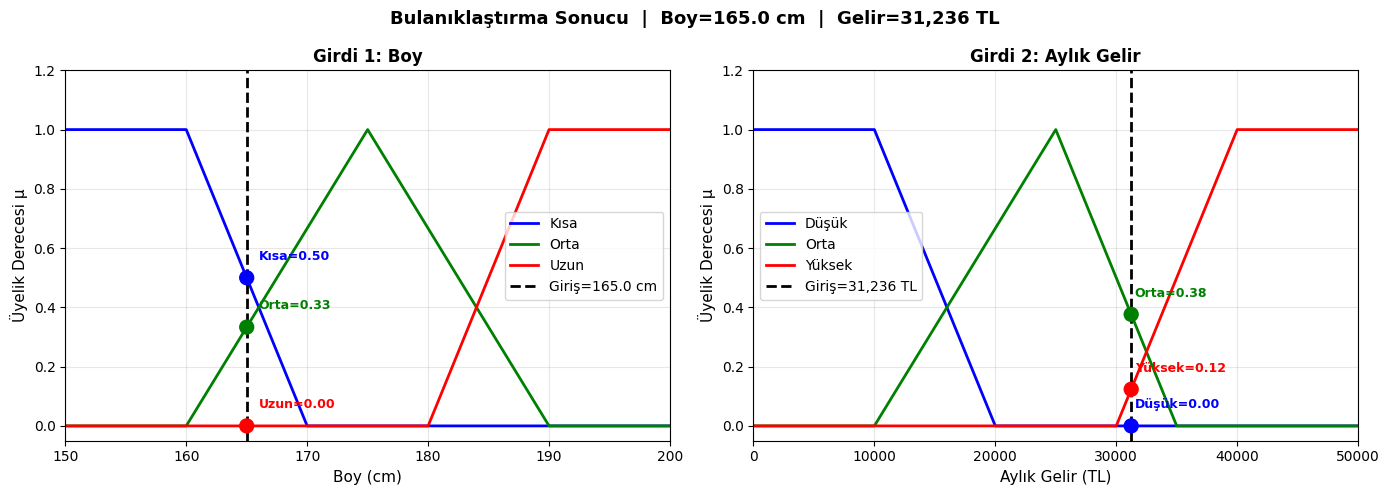

In [21]:
# GİRİLEN DEĞERLERİ GRAFİKTE GÖSTERME KISMI

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Bulanıklaştırma Sonucu  |  Boy={boy_giris} cm  |  Gelir={gelir_giris:,.0f} TL",
             fontsize=13, fontweight='bold')

# --- Boy grafiği ---
ax1 = axes[0]
ax1.plot(boy_aralik, mu_kisa, 'b-', linewidth=2, label='Kısa')
ax1.plot(boy_aralik, mu_orta, 'g-', linewidth=2, label='Orta')
ax1.plot(boy_aralik, mu_uzun, 'r-', linewidth=2, label='Uzun')
ax1.axvline(x=boy_giris, color='black', linestyle='--', linewidth=2, label=f'Giriş={boy_giris} cm')
ax1.scatter([boy_giris]*3, [b_kisa, b_orta, b_uzun], color=['blue','green','red'], s=100, zorder=5)
ax1.annotate(f'Kısa={b_kisa:.2f}', xy=(boy_giris, b_kisa), xytext=(boy_giris+1, b_kisa+0.06),
             fontsize=9, color='blue', fontweight='bold')
ax1.annotate(f'Orta={b_orta:.2f}', xy=(boy_giris, b_orta), xytext=(boy_giris+1, b_orta+0.06),
             fontsize=9, color='green', fontweight='bold')
ax1.annotate(f'Uzun={b_uzun:.2f}', xy=(boy_giris, b_uzun), xytext=(boy_giris+1, b_uzun+0.06),
             fontsize=9, color='red', fontweight='bold')
ax1.set_xlabel('Boy (cm)', fontsize=11)
ax1.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax1.set_title('Girdi 1: Boy', fontsize=12, fontweight='bold')
ax1.set_ylim(-0.05, 1.2)
ax1.set_xlim(150, 200)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Gelir grafiği ---
ax2 = axes[1]
ax2.plot(gelir_aralik, mu_dusuk,  'b-', linewidth=2, label='Düşük')
ax2.plot(gelir_aralik, mu_orta_g, 'g-', linewidth=2, label='Orta')
ax2.plot(gelir_aralik, mu_yuksek, 'r-', linewidth=2, label='Yüksek')
ax2.axvline(x=gelir_giris, color='black', linestyle='--', linewidth=2, label=f'Giriş={gelir_giris:,.0f} TL')
ax2.scatter([gelir_giris]*3, [g_dusuk, g_orta, g_yuksek], color=['blue','green','red'], s=100, zorder=5)
ax2.annotate(f'Düşük={g_dusuk:.2f}',  xy=(gelir_giris, g_dusuk),  xytext=(gelir_giris+300, g_dusuk+0.06),
             fontsize=9, color='blue', fontweight='bold')
ax2.annotate(f'Orta={g_orta:.2f}',    xy=(gelir_giris, g_orta),   xytext=(gelir_giris+300, g_orta+0.06),
             fontsize=9, color='green', fontweight='bold')
ax2.annotate(f'Yüksek={g_yuksek:.2f}',xy=(gelir_giris, g_yuksek), xytext=(gelir_giris+300, g_yuksek+0.06),
             fontsize=9, color='red', fontweight='bold')
ax2.set_xlabel('Aylık Gelir (TL)', fontsize=11)
ax2.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax2.set_title('Girdi 2: Aylık Gelir', fontsize=12, fontweight='bold')
ax2.set_ylim(-0.05, 1.2)
ax2.set_xlim(0, 50000)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

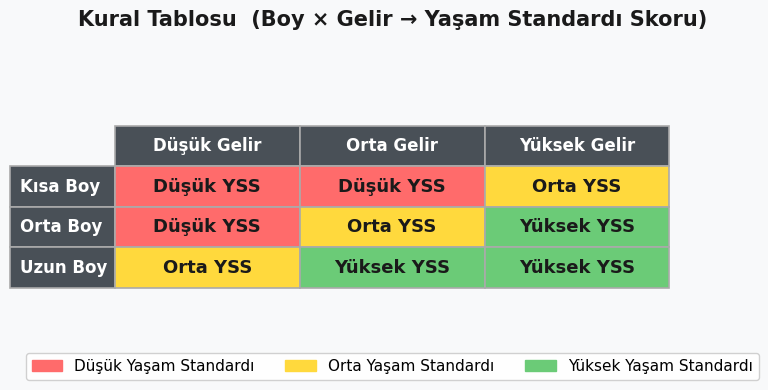


  ÇIKARIM - Aktif Kurallar
  IF boy=kisa  AND gelir=orta    → Düşük YSS     | min(0.500, 0.376) = 0.376
  IF boy=kisa  AND gelir=yuksek  → Orta YSS      | min(0.500, 0.124) = 0.124
  IF boy=orta  AND gelir=orta    → Orta YSS      | min(0.333, 0.376) = 0.333
  IF boy=orta  AND gelir=yuksek  → Yüksek YSS    | min(0.333, 0.124) = 0.124

  Birleştirilmiş Yaşam Standardı Skoru:
    Düşük YSS     : 0.3764
    Orta YSS      : 0.3333
    Yüksek YSS    : 0.1236


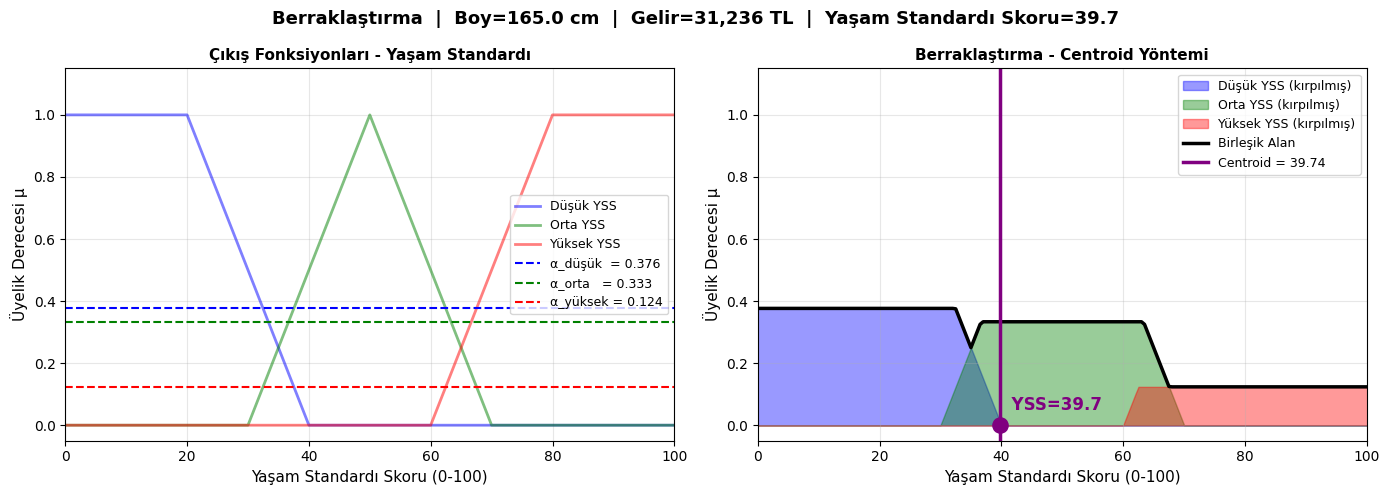


  SONUÇ  →  Yaşam Standardı Skoru = 39.74 / 100


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────
# ÇIKIŞ ÜYELİK FONKSİYONLARI
# ─────────────────────────────────────────────
def dusuk_skor(x):
    if x <= 20:   return 1.0
    elif x <= 40: return (40 - x) / 20
    else:         return 0.0

def orta_skor(x):
    if x <= 30:   return 0.0
    elif x <= 50: return (x - 30) / 20
    elif x <= 70: return (70 - x) / 20
    else:         return 0.0

def yuksek_skor(x):
    if x <= 60:   return 0.0
    elif x <= 80: return (x - 60) / 20
    else:         return 1.0

# ─────────────────────────────────────────────
# KURAL TABLOSU
# ─────────────────────────────────────────────
kural_tablosu = {
    ("kisa", "dusuk"):  "dusuk_skor",
    ("kisa", "orta"):   "dusuk_skor",
    ("kisa", "yuksek"): "orta_skor",
    ("orta", "dusuk"):  "dusuk_skor",
    ("orta", "orta"):   "orta_skor",
    ("orta", "yuksek"): "yuksek_skor",
    ("uzun", "dusuk"):  "orta_skor",
    ("uzun", "orta"):   "yuksek_skor",
    ("uzun", "yuksek"): "yuksek_skor",
}

# ─────────────────────────────────────────────
# KURAL TABLOSU GRAFİĞİ
# ─────────────────────────────────────────────
boy_kumeleri   = ["Kısa Boy",  "Orta Boy",  "Uzun Boy"]
gelir_kumeleri = ["Düşük Gelir", "Orta Gelir", "Yüksek Gelir"]

tablo_degerleri = [
    ["Düşük YSS", "Düşük YSS", "Orta YSS" ],
    ["Düşük YSS", "Orta YSS",  "Yüksek YSS"],
    ["Orta YSS",  "Yüksek YSS","Yüksek YSS"],
]

# YSS = Yaşam Standardı Skoru
renk_map = {
    "Düşük YSS":  "#FF6B6B",
    "Orta YSS":   "#FFD93D",
    "Yüksek YSS": "#6BCB77",
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

tablo = ax.table(
    cellText=tablo_degerleri,
    rowLabels=boy_kumeleri,
    colLabels=gelir_kumeleri,
    loc='center',
    cellLoc='center'
)

tablo.auto_set_font_size(False)
tablo.set_fontsize(13)
tablo.scale(1.6, 2.4)

# Hücre renklerini ve stilini ayarlama kısmı
for (satir, sutun), hucre in tablo.get_celld().items():
    hucre.set_edgecolor('#AAAAAA')
    hucre.set_linewidth(1.2)

    # Başlık satırı ve başlık sütunu
    if satir == 0 and sutun == -1:
        hucre.set_facecolor('#343A40')
        hucre.set_text_props(color='white', fontweight='bold', fontsize=12)
    elif satir == 0:
        hucre.set_facecolor('#495057')
        hucre.set_text_props(color='white', fontweight='bold', fontsize=12)
    elif sutun == -1:
        hucre.set_facecolor('#495057')
        hucre.set_text_props(color='white', fontweight='bold', fontsize=12)
    else:
        deger = tablo_degerleri[satir - 1][sutun]
        hucre.set_facecolor(renk_map[deger])
        hucre.set_text_props(color='#1A1A1A', fontweight='bold', fontsize=13)

# Gösterge
patch_dusuk  = mpatches.Patch(color=renk_map["Düşük YSS"],  label='Düşük Yaşam Standardı')
patch_orta   = mpatches.Patch(color=renk_map["Orta YSS"],   label='Orta Yaşam Standardı')
patch_yuksek = mpatches.Patch(color=renk_map["Yüksek YSS"], label='Yüksek Yaşam Standardı')
ax.legend(handles=[patch_dusuk, patch_orta, patch_yuksek],
          loc='lower center', bbox_to_anchor=(0.5, -0.08),
          ncol=3, fontsize=11, framealpha=0.9)

ax.set_title("Kural Tablosu  (Boy × Gelir → Yaşam Standardı Skoru)",
             fontsize=15, fontweight='bold', pad=18, color='#1A1A1A')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# ÇIKARIM - Min-Max
# ─────────────────────────────────────────────
ates_degerleri = {"dusuk_skor": 0.0, "orta_skor": 0.0, "yuksek_skor": 0.0}

print("\n" + "="*62)
print("  ÇIKARIM - Aktif Kurallar")
print("="*62)

CIKIS_ETIKETI = {
    "dusuk_skor":  "Düşük YSS",
    "orta_skor":   "Orta YSS",
    "yuksek_skor": "Yüksek YSS"
}

for (boy_kume, gelir_kume), cikis_kume in kural_tablosu.items():
    mu_boy   = bulanik_boy[boy_kume]
    mu_gelir = bulanik_gelir[gelir_kume]
    ates     = min(mu_boy, mu_gelir)
    ates_degerleri[cikis_kume] = max(ates_degerleri[cikis_kume], ates)

    if ates > 0:
        print(f"  IF boy={boy_kume:<5} AND gelir={gelir_kume:<7} "
              f"→ {CIKIS_ETIKETI[cikis_kume]:<13} | min({mu_boy:.3f}, {mu_gelir:.3f}) = {ates:.3f}")

print("\n  Birleştirilmiş Yaşam Standardı Skoru:")
for kume, deger in ates_degerleri.items():
    print(f"    {CIKIS_ETIKETI[kume]:<14}: {deger:.4f}")

# ─────────────────────────────────────────────
# BERRAKLAŞTIRMA + GRAFİK
# ─────────────────────────────────────────────
skor_aralik = np.arange(0, 101, 0.5)

mu_d = np.array([min(dusuk_skor(x),  ates_degerleri["dusuk_skor"])  for x in skor_aralik])
mu_o = np.array([min(orta_skor(x),   ates_degerleri["orta_skor"])   for x in skor_aralik])
mu_y = np.array([min(yuksek_skor(x), ates_degerleri["yuksek_skor"]) for x in skor_aralik])

mu_bilesik = np.maximum(np.maximum(mu_d, mu_o), mu_y)

payda  = np.sum(mu_bilesik)
skor   = np.sum(skor_aralik * mu_bilesik) / payda if payda != 0 else 50.0

# Orijinal fonksiyonlar (solüfigür için)
mu_d_tam = np.array([dusuk_skor(x)  for x in skor_aralik])
mu_o_tam = np.array([orta_skor(x)   for x in skor_aralik])
mu_y_tam = np.array([yuksek_skor(x) for x in skor_aralik])

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(
    f"Berraklaştırma  |  Boy={boy_giris} cm  |  Gelir={gelir_giris:,.0f} TL  |  Yaşam Standardı Skoru={skor:.1f}",
    fontsize=13, fontweight='bold'
)

# Sol: orijinal fonksiyonlar - Çıkış Fonksiyonu
ax1 = axes[0]
ax1.plot(skor_aralik, mu_d_tam, 'b-', lw=2, label='Düşük YSS',  alpha=0.5)
ax1.plot(skor_aralik, mu_o_tam, 'g-', lw=2, label='Orta YSS',   alpha=0.5)
ax1.plot(skor_aralik, mu_y_tam, 'r-', lw=2, label='Yüksek YSS', alpha=0.5)
ax1.axhline(y=ates_degerleri["dusuk_skor"],  color='blue',  ls='--', lw=1.5,
            label=f'α_düşük  = {ates_degerleri["dusuk_skor"]:.3f}')
ax1.axhline(y=ates_degerleri["orta_skor"],   color='green', ls='--', lw=1.5,
            label=f'α_orta   = {ates_degerleri["orta_skor"]:.3f}')
ax1.axhline(y=ates_degerleri["yuksek_skor"], color='red',   ls='--', lw=1.5,
            label=f'α_yüksek = {ates_degerleri["yuksek_skor"]:.3f}')
ax1.set_xlabel('Yaşam Standardı Skoru (0-100)', fontsize=11)
ax1.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax1.set_title('Çıkış Fonksiyonları - Yaşam Standardı', fontsize=11, fontweight='bold')
ax1.set_ylim(-0.05, 1.15); ax1.set_xlim(0, 100)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Sağ: kırpılmış alanlar + centroid
ax2 = axes[1]
ax2.fill_between(skor_aralik, mu_d, alpha=0.4, color='blue',  label='Düşük YSS (kırpılmış)')
ax2.fill_between(skor_aralik, mu_o, alpha=0.4, color='green', label='Orta YSS (kırpılmış)')
ax2.fill_between(skor_aralik, mu_y, alpha=0.4, color='red',   label='Yüksek YSS (kırpılmış)')
ax2.plot(skor_aralik, mu_bilesik, 'k-', lw=2.5, label='Birleşik Alan')
ax2.axvline(x=skor, color='purple', lw=2.5, label=f'Centroid = {skor:.2f}')
ax2.scatter([skor], [0], color='purple', s=120, zorder=5)
ax2.annotate(f'  YSS={skor:.1f}', xy=(skor, 0.05), fontsize=12,
             color='purple', fontweight='bold')
ax2.set_xlabel('Yaşam Standardı Skoru (0-100)', fontsize=11)
ax2.set_ylabel('Üyelik Derecesi μ', fontsize=11)
ax2.set_title('Berraklaştırma - Centroid Yöntemi', fontsize=11, fontweight='bold')
ax2.set_ylim(-0.05, 1.15); ax2.set_xlim(0, 100)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*58)
print(f"  SONUÇ  →  Yaşam Standardı Skoru = {skor:.2f} / 100")
print("="*58)